# HW4 Lab

We have seen rootfinding methods that have linear, superlinear, and quadratic convergence. We know that the bisection method has at least linear convergence, the secant method has superlinear convergence, and Newton's method has quadratic convergence.  These are ordered from slowest to fastest.  In fact, quadratic convergence can be dramatically faster than linear convergence.  Today we'll explore this fact by implementing these methods, testing them on a given rootfinding problem, and plotting the errors!

In [1]:
using Plots

### (a)

 Implement the bisection method in Julia.  Make sure to return a vector `x` that contains as entries the approximations $x_k$. 

In [2]:
# implement bisection method
# returns approximations from all iterations
function bisection(f, a, b, iterations)
    if f(a) * f(b) >= 0
        error("f(a) and f(b) must have opposite signs")
    end

    xs = []

    for i in 1:iterations
        midpoint = (a + b) / 2
        if f(midpoint) == 0
            return midpoint
        elseif f(midpoint) * f(a) < 0
            b = midpoint
        else
            a = midpoint
        end

        push!(xs, midpoint)
    end

    return xs
end

bisection (generic function with 1 method)

### (b)

Define $f(x) = \frac{1}{x-3} - 6$ in Julia and create a plot of this function over the interval $[3.1, 3.4]$.  Notice that there is a root at $19/6$.

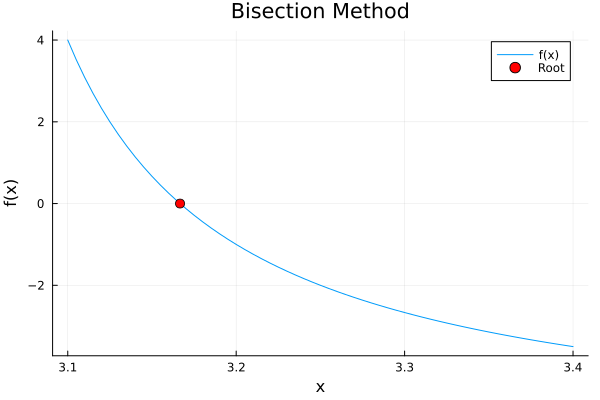

In [3]:
# define f
f(x) = 1 / (x - 3) - 6

# create plot of function
x = 3.1:0.005:3.4
y = f.(x)
plot(x, y, label="f(x)", title="Bisection Method", xlabel="x", ylabel="f(x)", legend=:topright)
plot!([19/6], [0], seriestype=:scatter, label="Root", color=:red, markersize=5) # add root to plot

### (c)

Apply the bisection method (initialized with $a_1 = 3.1$ and $b_1 = 3.5$), the secant method (initialized with $x_1 = 3.5$ and $x_2 = 3.1$), and Newton's method (initialized with $x_1 = 3.1$) to approximate this root.  You may copy the code for the secant method and Newton's method from our class notes.  (Each of these methods should converge with this proper initialization.) 

In [12]:
# secant
function secant(f, x0, x1, iterations)
    xs = []
    push!(xs, x0)
    push!(xs, x1)

    for i in 2:iterations
        if f(xs[i]) == f(xs[i - 1])
            error("Division by zero")
        end

        x_next = xs[i] - f(xs[i]) * (xs[i] - xs[i - 1]) / (f(xs[i]) - f(xs[i - 1]))
        push!(xs, x_next)
    end

    return xs
end

# newton's method
function newton(f, f_prime, x0, iterations)
    xs = [x0]

    for i in 1:iterations
        if f_prime(xs[i]) == 0
            error("Division by zero")
        end

        x_next = xs[i] - f(xs[i]) / f_prime(xs[i])
        push!(xs, x_next)
    end

    return xs
end

# derivative of f
f_prime(x) = -1 / ((x - 3)^2)

f_prime (generic function with 1 method)

In [19]:
# use the three methods to find the root
root_bisection = bisection(f, 3.1, 3.4, 10)
root_secant = secant(f, 3.5, 3.1, 10)
root_newton = newton(f, f_prime, 3.1, 10)

# print the final approximations
println("Bisection method root: ", root_bisection[end])
println("Secant method root: ", root_secant[end])
println("Newton's method root: ", root_newton[end])

Bisection method root: 3.16650390625
Secant method root: 3.166666666666295
Newton's method root: 3.1666666666666665


### (d) / (e)

Let $r = 19/6$ and calculate the errors $\epsilon_k = x_k - r$ for each method.  (You should have a vector of errors for each method, each with as many entries as iterations were run for that method.)

Create a single log-linear plot (yscale is logarithmic) which plots the magnitude of the errors for each of these methods.  (Exclude any error values that are 0.)

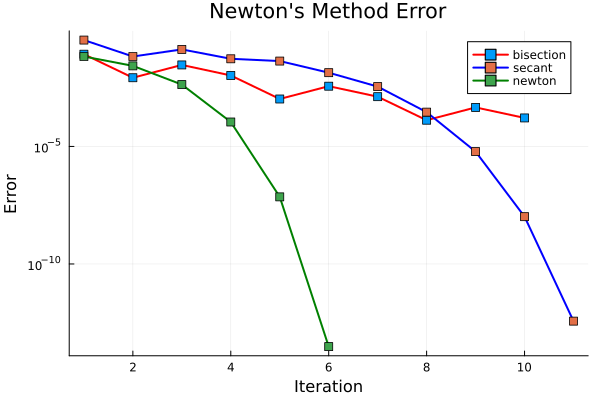

In [38]:
r = 19/6

# calculate erros
bisection_error = [abs(r - x) for x in root_bisection]
secant_error = [abs(r - x) for x in root_secant]
newton_error = [abs(r - x) for x in root_newton]

# plot errors, skip the ones that are too small
bisection_error = [x for x in bisection_error if x > eps()]
secant_error = [x for x in secant_error if x > eps()]
newton_error = [x for x in newton_error if x > eps()]

# plot the errors in scatter plot connected by lines
plot(bisection_error,
     title="Bisection Method Error",
     xlabel="Iteration",
     ylabel="Error",
     yaxis=:log,
     label="bisection",
     legend=:topright, 
     grid=true, 
     marker=:square, 
     linecolor=:red, 
     linewidth=2)
plot!(secant_error,
     title="Secant Method Error",
     xlabel="Iteration",
     ylabel="Error",
     yaxis=:log,
     label="secant",
     marker=:square, 
     linecolor=:blue, 
     linewidth=2)
plot!(newton_error,
     title="Newton's Method Error",
     xlabel="Iteration",
     ylabel="Error",
     yaxis=:log,
     label="newton",
     marker=:square, 
     linecolor=:green, 
     linewidth=2)

As we can see, Newton's method converges the fasted, followed by secant and then bisection.